#  Titanic Dataset - Refactored & Polished Analysis
**Author:** Zainab Mairaj  
**Objective:** Clean, visualize, and summarize key insights from the Titanic dataset following PEP 8 guidelines and professional formatting standards.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Set standard figure style aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load raw dataset directly from source
DATASET_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    titanic_df = pd.read_csv(DATASET_URL)
    print(f" Successfully loaded dataset with {titanic_df.shape[0]} rows and {titanic_df.shape[1]} columns.")
except Exception as e:
    print(f" Error loading dataset: {e}")

 Successfully loaded dataset with 891 rows and 12 columns.


In [2]:
# Create a copy to prevent modifying the raw data
cleaned_df = titanic_df.copy()

# 1. Impute missing numerical values with median (robust against outliers)
median_age = cleaned_df['Age'].median()
cleaned_df['Age'] = cleaned_df['Age'].fillna(median_age)

# 2. Drop high-null column ('Cabin' has >75% missing values)
cleaned_df.drop(columns=['Cabin'], inplace=True)

# 3. Drop remaining sparse missing values
cleaned_df.dropna(subset=['Embarked'], inplace=True)

print(" Preprocessing Complete:")
print(f"- Remaining missing values: {cleaned_df.isnull().sum().sum()}")
print(f"- Cleaned dataset dimensions: {cleaned_df.shape}")

 Preprocessing Complete:
- Remaining missing values: 0
- Cleaned dataset dimensions: (889, 11)


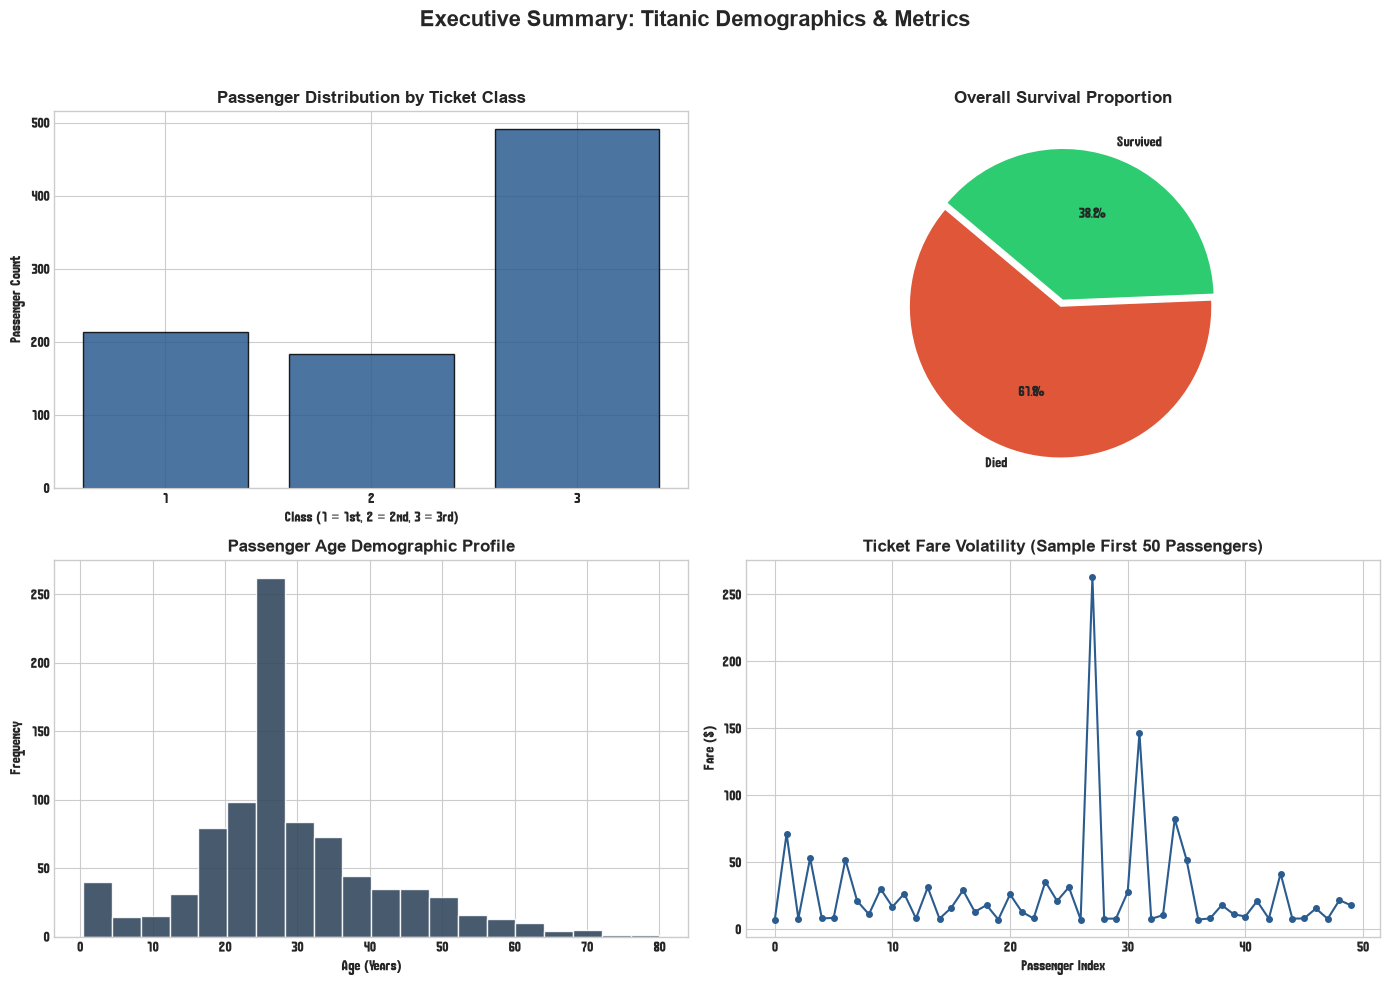

In [3]:
# Initialize dashboard grid figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Executive Summary: Titanic Demographics & Metrics', fontsize=16, fontweight='bold', y=0.98)

# Color Palette Definition
COLORS = {'primary': '#2b5c8f', 'secondary': '#e05638', 'accent': '#2ecc71', 'neutral': '#34495e'}

# Chart 1: Passenger Class Distribution
class_counts = cleaned_df['Pclass'].value_counts().sort_index()
axes[0, 0].bar(class_counts.index.astype(str), class_counts.values, color=COLORS['primary'], edgecolor='black', alpha=0.85)
axes[0, 0].set_title('Passenger Distribution by Ticket Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
axes[0, 0].set_ylabel('Passenger Count')

# Chart 2: Survival Percentage Breakdown
survival_counts = cleaned_df['Survived'].value_counts()
axes[0, 1].pie(
    survival_counts.values, 
    labels=['Died', 'Survived'], 
    autopct='%1.1f%%', 
    colors=[COLORS['secondary'], COLORS['accent']], 
    startangle=140,
    explode=(0.05, 0)
)
axes[0, 1].set_title('Overall Survival Proportion', fontsize=12, fontweight='bold')

# Chart 3: Passenger Age Distribution
axes[1, 0].hist(cleaned_df['Age'], bins=20, color=COLORS['neutral'], edgecolor='white', alpha=0.9)
axes[1, 0].set_title('Passenger Age Demographic Profile', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age (Years)')
axes[1, 0].set_ylabel('Frequency')

# Chart 4: Ticket Fare Distribution Trend
sample_fare = cleaned_df['Fare'].head(50)
axes[1, 1].plot(sample_fare.index, sample_fare.values, color=COLORS['primary'], marker='o', linewidth=1.5, markersize=4)
axes[1, 1].set_title('Ticket Fare Volatility (Sample First 50 Passengers)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Passenger Index')
axes[1, 1].set_ylabel('Fare ($)')

# Overall layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()